# Домашнее задание 5

**Задача:** Бинарная классификация - предсказание статуса курильщика
**Соревнование:** [AITH DL Competition - Tabular data](https://www.kaggle.com/competitions/aith-dl-competition-tabular-data-2025-2)
**Метрика:** ROC AUC
**Ограничение:** Только нейросетевые модели

## 1. Загрузка данных

In [1]:
# Скачивание данных с Kaggle
!pip install kaggle --quiet
!kaggle competitions download -c aith-dl-competition-tabular-data-2025-2
!unzip -o aith-dl-competition-tabular-data-2025-2.zip
!ls -la

aith-dl-competition-tabular-data-2025-2.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  aith-dl-competition-tabular-data-2025-2.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
total 5380
drwxrwxr-x 3 dima dima    4096 Jan  8 23:31 .
drwxrwxr-x 7 dima dima    4096 Jan  8 22:31 ..
-rw-rw-r-- 1 dima dima  744118 Dec 29 13:49 aith-dl-competition-tabular-data-2025-2.zip
-rw-rw-r-- 1 dima dima  213068 Jan  8 23:01 best_model_fe.pt
-rw-rw-r-- 1 dima dima   54261 Jan  8 22:50 best_model.pt
-rw------- 1 dima dima     171 Jan  8 23:27 .gitignore
-rw------- 1 dima dima  791957 Jan  8 23:25 hw5_smoking.ipynb
drwxrwxr-x 2 dima dima    4096 Jan  8 22:51 .ipynb_checkpoints
-rw-rw-r-- 1 dima dima  100011 Dec 29 13:49 sample_submission.csv
-rw-rw-r-- 1 dima dima  171114 Jan  8 22:51 submission_baseline.csv
-rw-rw-r-- 1 dima dima  170464 Jan  8 23:02 submission_improved.csv
-rw-rw-r-- 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
# Загрузка данных
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f'Train: {train_df.shape}')
print(f'Test: {test_df.shape}')
print(f'\nКолонки: {train_df.columns.tolist()}')

Train: (15000, 24)
Test: (10000, 23)

Колонки: ['id', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries', 'smoking']


In [4]:
train_df.head()

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,35.0,175.0,75.0,86.5,1.2,1.2,1.0,1.0,127.0,...,58.0,108.0,15.6,1.0,0.9,17.0,14.0,21.0,0.0,0.0
1,1,45.0,155.0,60.0,82.0,1.2,1.0,1.0,1.0,129.0,...,50.0,110.0,14.0,1.0,0.7,22.0,18.0,14.0,0.0,0.0
2,2,35.0,175.0,60.0,74.0,1.2,1.2,1.0,1.0,100.0,...,58.0,116.0,14.8,1.0,0.9,20.0,15.0,16.0,0.0,1.0
3,3,60.0,160.0,55.0,74.0,1.2,1.5,1.0,1.0,139.0,...,73.0,95.0,15.1,1.0,0.7,47.0,31.0,15.0,0.0,0.0
4,4,40.0,160.0,55.0,71.0,0.9,1.2,1.0,1.0,100.0,...,66.0,103.0,13.1,1.0,0.6,24.0,21.0,13.0,0.0,0.0


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   15000 non-null  int64  
 1   age                  15000 non-null  float64
 2   height(cm)           15000 non-null  float64
 3   weight(kg)           15000 non-null  float64
 4   waist(cm)            15000 non-null  float64
 5   eyesight(left)       15000 non-null  float64
 6   eyesight(right)      15000 non-null  float64
 7   hearing(left)        15000 non-null  float64
 8   hearing(right)       15000 non-null  float64
 9   systolic             15000 non-null  float64
 10  relaxation           15000 non-null  float64
 11  fasting blood sugar  15000 non-null  float64
 12  Cholesterol          15000 non-null  float64
 13  triglyceride         15000 non-null  float64
 14  HDL                  15000 non-null  float64
 15  LDL                  15000 non-null 

In [6]:
# Распределение таргета
print('Распределение таргета:')
print(train_df['smoking'].value_counts())
print(f'\nБаланс классов: {train_df["smoking"].mean():.2%} курильщиков')

Распределение таргета:
smoking
0.0    9443
1.0    5557
Name: count, dtype: int64

Баланс классов: 37.05% курильщиков


In [7]:
# Статистика по признакам
stats = train_df.describe().T
print(stats.to_string())

                       count         mean          std    min      25%      50%       75%      max
id                   15000.0  7499.500000  4330.271354    0.0  3749.75  7499.50  11249.25  14999.0
age                  15000.0    42.776000    10.436367   20.0    40.00    40.00     50.00     85.0
height(cm)           15000.0   164.764333     8.503976  140.0   160.00   165.00    170.00    190.0
weight(kg)           15000.0    64.417333    11.000541   35.0    55.00    65.00     70.00    115.0
waist(cm)            15000.0    80.407413     7.945482   57.4    75.00    80.05     86.00    114.0
eyesight(left)       15000.0     1.033813     0.316024    0.0     0.80     1.00      1.20      9.9
eyesight(right)      15000.0     1.028093     0.295498    0.1     0.80     1.00      1.20      9.9
hearing(left)        15000.0     1.005867     0.076372    1.0     1.00     1.00      1.00      2.0
hearing(right)       15000.0     1.005000     0.070536    1.0     1.00     1.00      1.00      2.0
systolic  

In [8]:
# Проверка пропусков
print('Пропуски в train:')
print(train_df.isnull().sum().sum())
print('\nПропуски в test:')
print(test_df.isnull().sum().sum())

Пропуски в train:
0

Пропуски в test:
0


In [9]:
# Корреляция признаков с таргетом
feature_cols = [c for c in train_df.columns if c not in ['id', 'smoking']]
correlations = train_df[feature_cols + ['smoking']].corr()['smoking'].drop('smoking').sort_values(key=abs, ascending=False)

print('Корреляция с таргетом (по модулю):')
for feat, corr in correlations.items():
    print(f'  {feat}: {corr:.4f}')

Корреляция с таргетом (по модулю):
  hemoglobin: 0.5009
  height(cm): 0.4851
  weight(kg): 0.4007
  triglyceride: 0.3594
  Gtp: 0.3528
  serum creatinine: 0.3515
  waist(cm): 0.3074
  HDL: -0.2999
  ALT: 0.2497
  age: -0.1888
  relaxation: 0.1675
  eyesight(right): 0.1521
  dental caries: 0.1441
  eyesight(left): 0.1318
  systolic: 0.1291
  fasting blood sugar: 0.1179
  AST: 0.1121
  LDL: -0.0391
  Cholesterol: -0.0363
  hearing(left): -0.0119
  hearing(right): -0.0094
  Urine protein: -0.0024


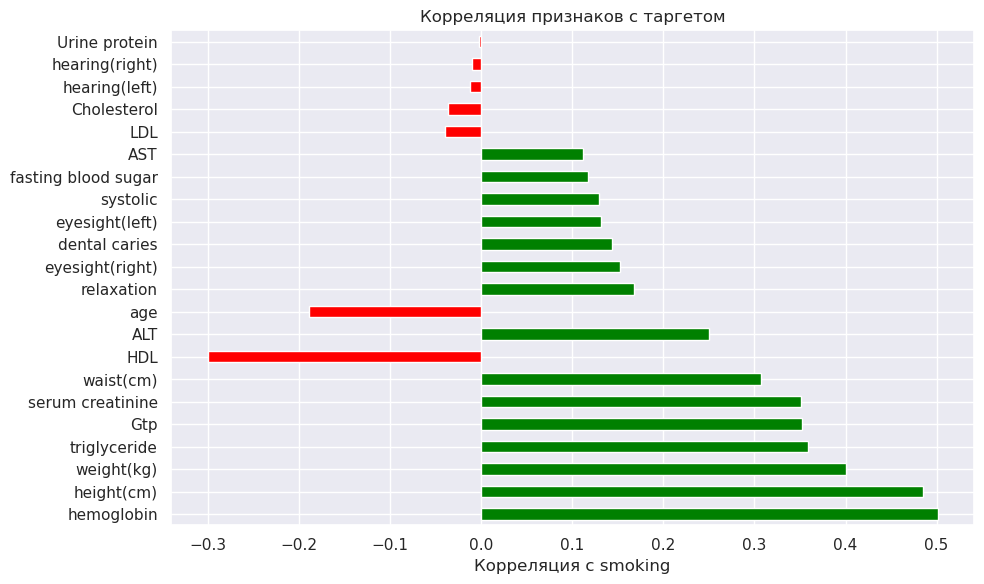

In [10]:
# Визуализация корреляции с таргетом
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlations])
plt.xlabel('Корреляция с smoking')
plt.title('Корреляция признаков с таргетом')
plt.tight_layout()
plt.show()

Топ-6 признаков: ['hemoglobin', 'height(cm)', 'weight(kg)', 'triglyceride', 'Gtp', 'serum creatinine']

Средние значения по классам:
  hemoglobin: не курит=13.98, курит=15.43, разница=+1.46
  height(cm): не курит=161.60, курит=170.14, разница=+8.54
  weight(kg): не курит=61.04, курит=70.16, разница=+9.13
  triglyceride: не курит=89.27, курит=125.19, разница=+35.92
  Gtp: не курит=21.00, курит=35.40, разница=+14.40
  serum creatinine: не курит=0.82, курит=0.94, разница=+0.12


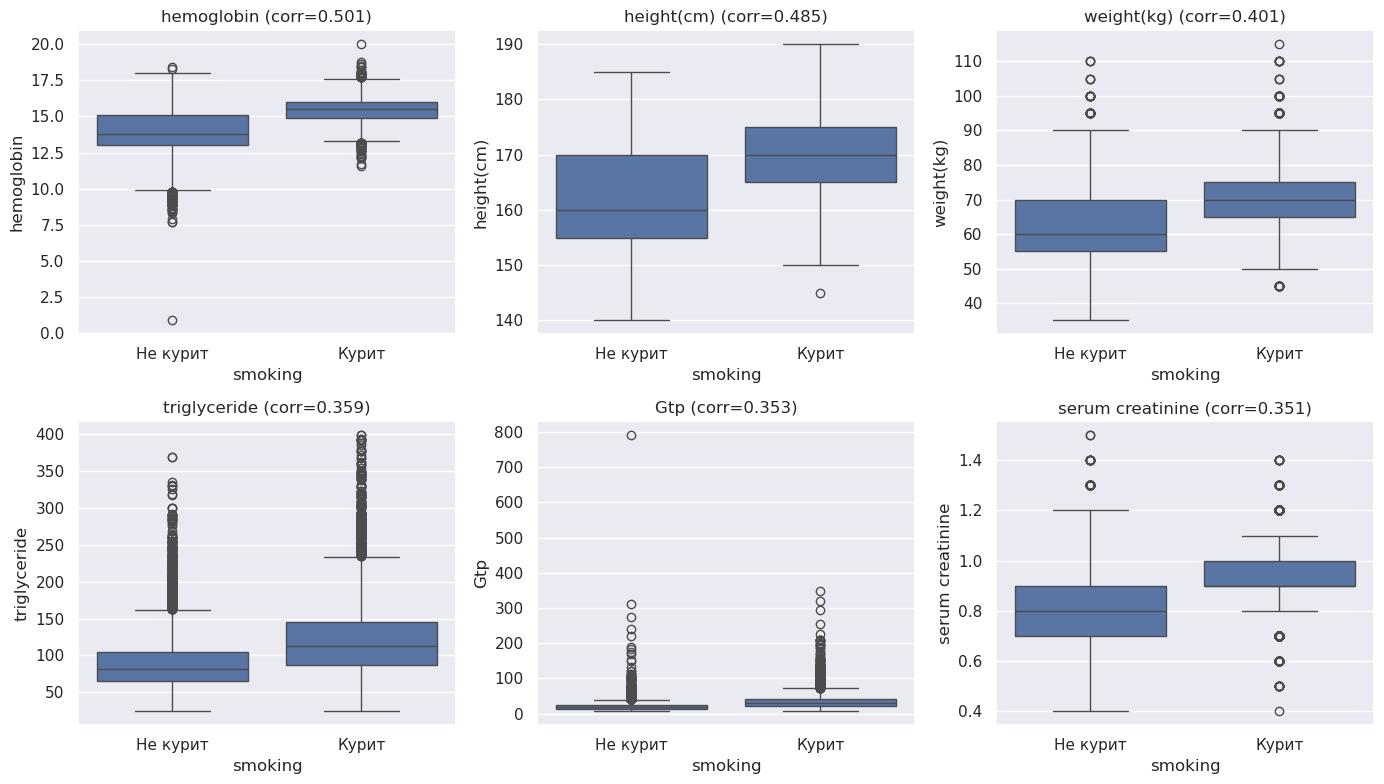

In [11]:
# Распределение топ-6 признаков по классам
top_features = correlations.head(6).index.tolist()
print(f'Топ-6 признаков: {top_features}')

# Средние значения по классам
print('\nСредние значения по классам:')
for feat in top_features:
    mean_0 = train_df[train_df['smoking'] == 0][feat].mean()
    mean_1 = train_df[train_df['smoking'] == 1][feat].mean()
    print(f'  {feat}: не курит={mean_0:.2f}, курит={mean_1:.2f}, разница={mean_1-mean_0:+.2f}')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.boxplot(data=train_df, x='smoking', y=feat, ax=axes[i])
    axes[i].set_title(f'{feat} (corr={correlations[feat]:.3f})')
    axes[i].set_xticklabels(['Не курит', 'Курит'])

plt.tight_layout()
plt.show()

Сильные корреляции между признаками (|r| > 0.5):
  height(cm) <-> weight(kg): 0.713
  height(cm) <-> hemoglobin: 0.622
  height(cm) <-> serum creatinine: 0.538
  weight(kg) <-> waist(cm): 0.834
  weight(kg) <-> hemoglobin: 0.576
  eyesight(left) <-> eyesight(right): 0.673
  systolic <-> relaxation: 0.757
  Cholesterol <-> LDL: 0.854
  triglyceride <-> HDL: -0.506
  hemoglobin <-> serum creatinine: 0.560
  hemoglobin <-> smoking: 0.501
  AST <-> ALT: 0.709
  ALT <-> Gtp: 0.500


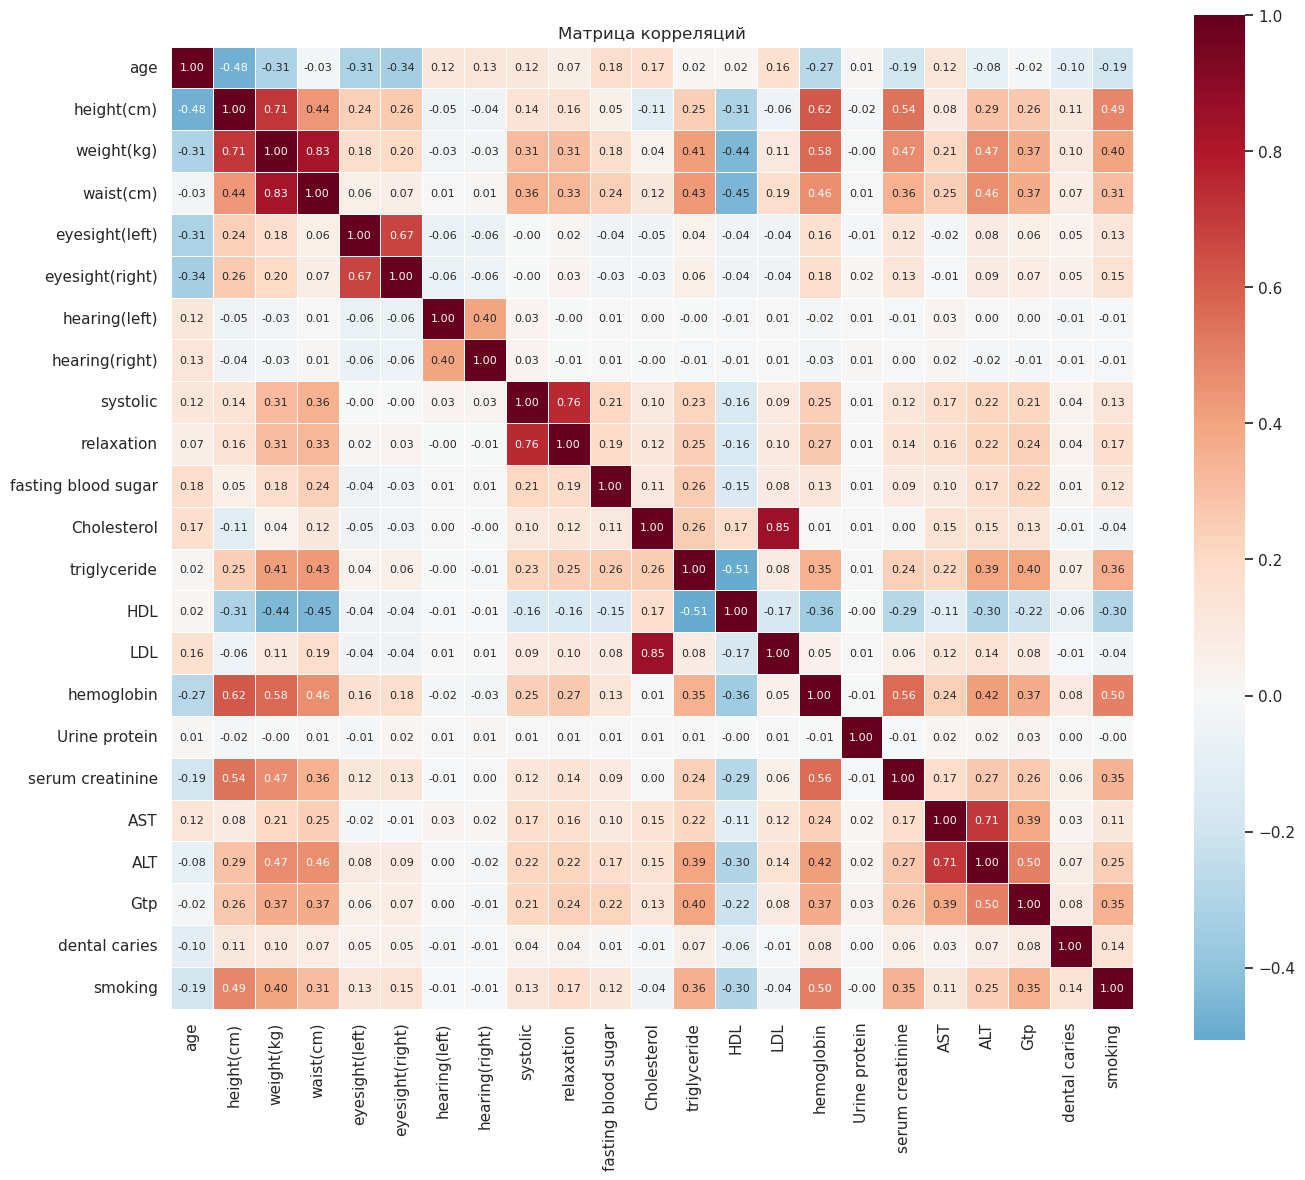

In [12]:
# Тепловая карта корреляций
corr_matrix = train_df[feature_cols + ['smoking']].corr()

# Вывод сильных корреляций между признаками (> 0.5)
print('Сильные корреляции между признаками (|r| > 0.5):')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.5:
            print(f'  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr:.3f}')

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

## 2. Выводы EDA

**Ключевые наблюдения:**

1. **Данные чистые** - нет пропусков, 22 признака, умеренный дисбаланс классов (37% курильщиков)

2. **Топ предикторы** (по корреляции с таргетом):
   - hemoglobin: 0.50, height: 0.49, weight: 0.40
   - triglyceride: 0.36, Gtp: 0.35, serum creatinine: 0.35
   - HDL: -0.30 (отрицательная корреляция)

3. **Скрытый гендерный фактор** - рост, вес, гемоглобин сильно коррелируют с курением, что указывает на то, что мужчины (физиологически крупнее) курят чаще. Нет явного признака пола.

4. **Мультиколлинеарность**:
   - weight - waist: 0.83
   - Cholesterol - LDL: 0.85
   - systolic - relaxation: 0.76
   - AST - ALT: 0.71

5. **Слабые признаки** (|r| < 0.05): hearing, Urine protein

**План для модели:**
- Нормализация признаков (StandardScaler)
- Возможно: BMI, waist-to-height ratio
- Базовый MLP - улучшения - сабмит

## 3. Baseline MLP

In [13]:
# Подготовка данных
feature_cols = [c for c in train_df.columns if c not in ['id', 'smoking']]
X = train_df[feature_cols].values
y = train_df['smoking'].values
X_test = test_df[feature_cols].values

# Train/Val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Нормализация
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test_scaled.shape}')

Train: (12000, 22), Val: (3000, 22), Test: (10000, 22)


In [14]:
# PyTorch DataLoaders
BATCH_SIZE = 256

train_dataset = TensorDataset(
    torch.FloatTensor(X_train), 
    torch.FloatTensor(y_train)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val), 
    torch.FloatTensor(y_val)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train batches: 47, Val batches: 12


In [15]:
# Baseline MLP модель
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64], dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)

# Создание модели
input_dim = X_train.shape[1]
model = BaselineMLP(input_dim, hidden_dims=[128, 64], dropout=0.3).to(device)
print(model)
print(f'\nВсего параметров: {sum(p.numel() for p in model.parameters()):,}')

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

Всего параметров: 11,649


In [16]:
# Функции обучения и валидации
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(X_batch)
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    roc_auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, roc_auc

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item() * len(X_batch)
            all_preds.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    roc_auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, roc_auc

print('Функции обучения готовы')

Функции обучения готовы


In [17]:
# Обучение модели
EPOCHS = 100
LR = 1e-3
PATIENCE = 10

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

best_val_auc = 0
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}

for epoch in range(EPOCHS):
    train_loss, train_auc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_auc = validate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    
    scheduler.step(val_auc)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f}, AUC: {train_auc:.4f} | Val Loss: {val_loss:.4f}, AUC: {val_auc:.4f}')
    
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

print(f'\nЛучший Val ROC-AUC: {best_val_auc:.4f}')

Epoch 10/100 | Train Loss: 0.4021, AUC: 0.8843 | Val Loss: 0.3982, AUC: 0.8840
Epoch 20/100 | Train Loss: 0.3962, AUC: 0.8882 | Val Loss: 0.3957, AUC: 0.8865

Early stopping at epoch 29

Лучший Val ROC-AUC: 0.8867


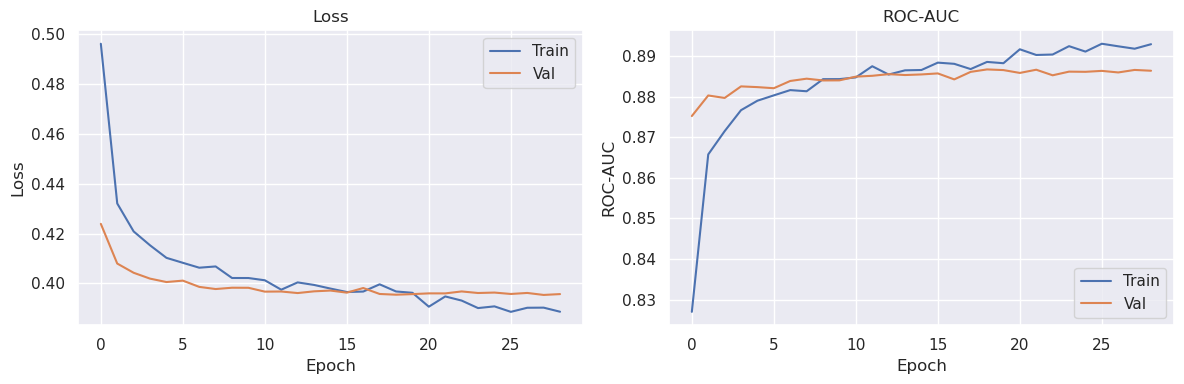

Финальные результаты:
  Train ROC-AUC: 0.8929
  Val ROC-AUC: 0.8863
  Best Val ROC-AUC: 0.8867


In [18]:
# Визуализация обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['train_auc'], label='Train')
axes[1].plot(history['val_auc'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Финальные результаты:')
print(f'  Train ROC-AUC: {history["train_auc"][-1]:.4f}')
print(f'  Val ROC-AUC: {history["val_auc"][-1]:.4f}')
print(f'  Best Val ROC-AUC: {best_val_auc:.4f}')

In [19]:
# Загрузка лучшей модели и предсказания на тесте
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

test_tensor = torch.FloatTensor(X_test_scaled).to(device)
with torch.no_grad():
    test_preds = torch.sigmoid(model(test_tensor)).cpu().numpy()

# Создание submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'smoking': test_preds
})
submission.to_csv('submission_baseline.csv', index=False)
print(f'Submission сохранен: submission_baseline.csv')
print(submission.head())

Submission сохранен: submission_baseline.csv
      id   smoking
0  15000  0.190993
1  15001  0.001653
2  15002  0.025793
3  15003  0.479590
4  15004  0.004772


## 4. Улучшенная модель

**Улучшения:**
1. Feature Engineering: BMI, waist-to-height ratio, взаимодействия признаков
2. Более глубокая архитектура
3. Увеличенный Dropout для регуляризации

In [20]:
# Feature Engineering
def add_features(df):
    df = df.copy()
    
    # BMI (индекс массы тела)
    df['BMI'] = df['weight(kg)'] / (df['height(cm)'] / 100) ** 2
    
    # Waist-to-height ratio (отношение талии к росту)
    df['waist_height_ratio'] = df['waist(cm)'] / df['height(cm)']
    
    # Средний показатель зрения
    df['eyesight_avg'] = (df['eyesight(left)'] + df['eyesight(right)']) / 2
    
    # Среднее давление
    df['BP_avg'] = (df['systolic'] + df['relaxation']) / 2
    
    # Пульсовое давление
    df['pulse_pressure'] = df['systolic'] - df['relaxation']
    
    # Liver score (печеночные ферменты)
    df['liver_score'] = df['AST'] + df['ALT'] + df['Gtp']
    
    # ALT/AST ratio (De Ritis ratio)
    df['alt_ast_ratio'] = df['ALT'] / (df['AST'] + 1)
    
    # Триглицериды / HDL (маркер риска)
    df['trig_hdl_ratio'] = df['triglyceride'] / (df['HDL'] + 1)
    
    # Non-HDL cholesterol
    df['non_hdl_chol'] = df['Cholesterol'] - df['HDL']
    
    return df

# Применяем feature engineering
train_df_fe = add_features(train_df)
test_df_fe = add_features(test_df)

print(f'Признаков до FE: {len(feature_cols)}')
new_feature_cols = [c for c in train_df_fe.columns if c not in ['id', 'smoking']]
print(f'Признаков после FE: {len(new_feature_cols)}')
print(f'Новые признаки: {[c for c in new_feature_cols if c not in feature_cols]}')

Признаков до FE: 22
Признаков после FE: 31
Новые признаки: ['BMI', 'waist_height_ratio', 'eyesight_avg', 'BP_avg', 'pulse_pressure', 'liver_score', 'alt_ast_ratio', 'trig_hdl_ratio', 'non_hdl_chol']


In [21]:
# Подготовка данных с новыми признаками
X_fe = train_df_fe[new_feature_cols].values
y_fe = train_df_fe['smoking'].values
X_test_fe = test_df_fe[new_feature_cols].values

# Train/Val split
X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fe
)

# Нормализация
scaler_fe = StandardScaler()
X_train_fe = scaler_fe.fit_transform(X_train_fe)
X_val_fe = scaler_fe.transform(X_val_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

# DataLoaders
train_dataset_fe = TensorDataset(torch.FloatTensor(X_train_fe), torch.FloatTensor(y_train_fe))
val_dataset_fe = TensorDataset(torch.FloatTensor(X_val_fe), torch.FloatTensor(y_val_fe))

train_loader_fe = DataLoader(train_dataset_fe, batch_size=BATCH_SIZE, shuffle=True)
val_loader_fe = DataLoader(val_dataset_fe, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train FE: {X_train_fe.shape}, Val FE: {X_val_fe.shape}')

Train FE: (12000, 31), Val FE: (3000, 31)


In [22]:
# Улучшенная модель с residual connections
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], dropout=0.4):
        super().__init__()
        
        # Первый блок
        self.block1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        # Второй блок
        self.block2 = nn.Sequential(
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.BatchNorm1d(hidden_dims[1]),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        # Третий блок
        self.block3 = nn.Sequential(
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.BatchNorm1d(hidden_dims[2]),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        # Выходной слой
        self.output = nn.Linear(hidden_dims[2], 1)
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.output(x).squeeze(-1)

# Создание модели
input_dim_fe = X_train_fe.shape[1]
model_fe = ImprovedMLP(input_dim_fe, hidden_dims=[256, 128, 64], dropout=0.4).to(device)
print(model_fe)
print(f'\nВсего параметров: {sum(p.numel() for p in model_fe.parameters()):,}')

ImprovedMLP(
  (block1): Sequential(
    (0): Linear(in_features=31, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.4, inplace=False)
  )
  (block2): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.4, inplace=False)
  )
  (block3): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.4, inplace=False)
  )
  (output): Linear(in_features=64, out_features=1, bias=True)
)

Всего параметров: 50,305


In [23]:
# Обучение улучшенной модели
EPOCHS_FE = 150
LR_FE = 5e-4
PATIENCE_FE = 15

criterion_fe = nn.BCEWithLogitsLoss()
optimizer_fe = torch.optim.AdamW(model_fe.parameters(), lr=LR_FE, weight_decay=1e-3)
scheduler_fe = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fe, T_max=EPOCHS_FE)

best_val_auc_fe = 0
patience_counter_fe = 0
history_fe = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}

for epoch in range(EPOCHS_FE):
    train_loss, train_auc = train_epoch(model_fe, train_loader_fe, optimizer_fe, criterion_fe, device)
    val_loss, val_auc = validate(model_fe, val_loader_fe, criterion_fe, device)
    
    history_fe['train_loss'].append(train_loss)
    history_fe['val_loss'].append(val_loss)
    history_fe['train_auc'].append(train_auc)
    history_fe['val_auc'].append(val_auc)
    
    scheduler_fe.step()
    
    if val_auc > best_val_auc_fe:
        best_val_auc_fe = val_auc
        patience_counter_fe = 0
        torch.save(model_fe.state_dict(), 'best_model_fe.pt')
    else:
        patience_counter_fe += 1
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS_FE} | Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}')
    
    if patience_counter_fe >= PATIENCE_FE:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

print(f'\nЛучший Val ROC-AUC (improved): {best_val_auc_fe:.4f}')
print(f'Улучшение над baseline: {best_val_auc_fe - best_val_auc:+.4f}')

Epoch 10/150 | Train AUC: 0.8801 | Val AUC: 0.8851
Epoch 20/150 | Train AUC: 0.8843 | Val AUC: 0.8866
Epoch 30/150 | Train AUC: 0.8890 | Val AUC: 0.8864

Early stopping at epoch 30

Лучший Val ROC-AUC (improved): 0.8874
Улучшение над baseline: +0.0008


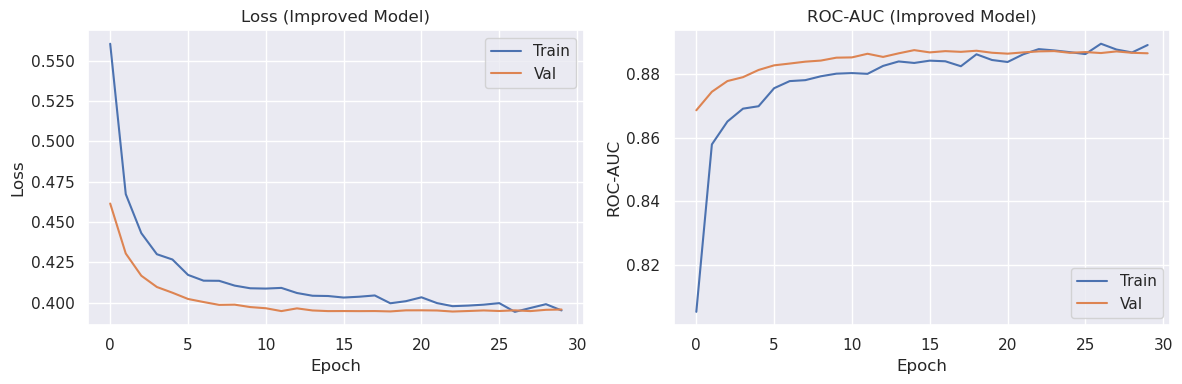

Сравнение результатов:
  Baseline Val ROC-AUC: 0.8867
  Improved Val ROC-AUC: 0.8874


In [24]:
# Визуализация обучения улучшенной модели
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_fe['train_loss'], label='Train')
axes[0].plot(history_fe['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss (Improved Model)')
axes[0].legend()

axes[1].plot(history_fe['train_auc'], label='Train')
axes[1].plot(history_fe['val_auc'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC (Improved Model)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Сравнение результатов:')
print(f'  Baseline Val ROC-AUC: {best_val_auc:.4f}')
print(f'  Improved Val ROC-AUC: {best_val_auc_fe:.4f}')

In [25]:
# Финальный submission с улучшенной моделью
model_fe.load_state_dict(torch.load('best_model_fe.pt'))
model_fe.eval()

test_tensor_fe = torch.FloatTensor(X_test_fe_scaled).to(device)
with torch.no_grad():
    test_preds_fe = torch.sigmoid(model_fe(test_tensor_fe)).cpu().numpy()

# Создание submission
submission_fe = pd.DataFrame({
    'id': test_df_fe['id'],
    'smoking': test_preds_fe
})
submission_fe.to_csv('submission_improved.csv', index=False)
print(f'Финальный submission сохранен: submission_improved.csv')
print(submission_fe.head())

Финальный submission сохранен: submission_improved.csv
      id   smoking
0  15000  0.203623
1  15001  0.002405
2  15002  0.035795
3  15003  0.535037
4  15004  0.004579


## 5. K-Fold CV + Ансамбль моделей

Для значительного улучшения результата:
1. 5-Fold Cross-Validation
2. Обучение модели на каждом фолде
3. Усреднение предсказаний всех моделей

In [26]:
from sklearn.model_selection import StratifiedKFold

# Расширенный Feature Engineering
def add_features_v2(df):
    df = df.copy()
    
    # Базовые производные
    df['BMI'] = df['weight(kg)'] / (df['height(cm)'] / 100) ** 2
    df['waist_height_ratio'] = df['waist(cm)'] / df['height(cm)']
    df['waist_weight_ratio'] = df['waist(cm)'] / df['weight(kg)']
    
    # Зрение
    df['eyesight_avg'] = (df['eyesight(left)'] + df['eyesight(right)']) / 2
    df['eyesight_diff'] = abs(df['eyesight(left)'] - df['eyesight(right)'])
    
    # Слух
    df['hearing_sum'] = df['hearing(left)'] + df['hearing(right)']
    
    # Давление
    df['BP_avg'] = (df['systolic'] + df['relaxation']) / 2
    df['pulse_pressure'] = df['systolic'] - df['relaxation']
    df['MAP'] = df['relaxation'] + df['pulse_pressure'] / 3  # Mean Arterial Pressure
    
    # Печеночные ферменты
    df['liver_score'] = df['AST'] + df['ALT'] + df['Gtp']
    df['alt_ast_ratio'] = df['ALT'] / (df['AST'] + 1)
    df['gtp_alt_ratio'] = df['Gtp'] / (df['ALT'] + 1)
    
    # Липидный профиль
    df['trig_hdl_ratio'] = df['triglyceride'] / (df['HDL'] + 1)
    df['non_hdl_chol'] = df['Cholesterol'] - df['HDL']
    df['ldl_hdl_ratio'] = df['LDL'] / (df['HDL'] + 1)
    df['chol_hdl_ratio'] = df['Cholesterol'] / (df['HDL'] + 1)
    
    # Гемоглобин нормализованный по весу
    df['hemo_weight'] = df['hemoglobin'] / df['weight(kg)'] * 100
    df['hemo_height'] = df['hemoglobin'] / df['height(cm)'] * 100
    
    # Креатинин
    df['creat_weight'] = df['serum creatinine'] / df['weight(kg)'] * 100
    
    # Сахар
    df['sugar_bmi'] = df['fasting blood sugar'] / df['BMI']
    
    return df

# Применяем расширенный FE
train_df_v2 = add_features_v2(train_df)
test_df_v2 = add_features_v2(test_df)

feature_cols_v2 = [c for c in train_df_v2.columns if c not in ['id', 'smoking']]
print(f'Всего признаков: {len(feature_cols_v2)}')

Всего признаков: 42


In [27]:
# Более мощная модель для K-Fold
class PowerfulMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128, 64], dropout=0.3):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.SiLU())  # Swish activation
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)

# Функция обучения одного фолда
def train_fold(X_train, y_train, X_val, y_val, X_test, fold_num, epochs=100, patience=15):
    # Нормализация
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # DataLoaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val_scaled), torch.FloatTensor(y_val))
    
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
    
    # Модель
    model = PowerfulMLP(X_train.shape[1], hidden_dims=[512, 256, 128, 64], dropout=0.3).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_val_auc = 0
    patience_counter = 0
    best_state = None
    
    for epoch in range(epochs):
        # Train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        # Validate
        model.eval()
        val_preds = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                outputs = torch.sigmoid(model(X_batch))
                val_preds.extend(outputs.cpu().numpy())
                val_labels.extend(y_batch.numpy())
        
        val_auc = roc_auc_score(val_labels, val_preds)
        scheduler.step()
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            break
    
    # Загружаем лучшую модель и делаем предсказания на тесте
    model.load_state_dict(best_state)
    model.eval()
    
    test_tensor = torch.FloatTensor(X_test_scaled).to(device)
    with torch.no_grad():
        test_preds = torch.sigmoid(model(test_tensor)).cpu().numpy()
    
    print(f'Fold {fold_num}: Val AUC = {best_val_auc:.4f}')
    return test_preds, best_val_auc

print('Функция обучения готова')

Функция обучения готова


In [28]:
# K-Fold Cross-Validation
N_FOLDS = 5

X_all = train_df_v2[feature_cols_v2].values
y_all = train_df_v2['smoking'].values
X_test_all = test_df_v2[feature_cols_v2].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_predictions = []
fold_aucs = []

print(f'Запуск {N_FOLDS}-Fold Cross-Validation...\n')

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    X_train_fold = X_all[train_idx]
    y_train_fold = y_all[train_idx]
    X_val_fold = X_all[val_idx]
    y_val_fold = y_all[val_idx]
    
    test_preds, val_auc = train_fold(
        X_train_fold, y_train_fold, 
        X_val_fold, y_val_fold, 
        X_test_all, fold,
        epochs=100, patience=15
    )
    
    fold_predictions.append(test_preds)
    fold_aucs.append(val_auc)

# Усреднение предсказаний
final_predictions = np.mean(fold_predictions, axis=0)

print(f'\n{"="*50}')
print(f'Средний Val AUC по фолдам: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')

Запуск 5-Fold Cross-Validation...

Fold 1: Val AUC = 0.8787
Fold 2: Val AUC = 0.8884
Fold 3: Val AUC = 0.8858
Fold 4: Val AUC = 0.8885
Fold 5: Val AUC = 0.8861

Средний Val AUC по фолдам: 0.8855 ± 0.0036


## 6. Супер-ансамбль

1. **Мульти-сид**: 3 разных random seed (42, 2024, 777)
2. **Мульти-архитектура**: 3 разные архитектуры MLP (широкая, глубокая, пирамидальная)
3. **7-Fold CV** для каждой комбинации
4. **Итого: 3 x 3 x 7 = 63 модели** в ансамбле

In [29]:
# Расширенный Feature Engineering для супер-ансамбля
def add_features_ultimate(df):
    df = df.copy()
    
    # Базовые производные
    df['BMI'] = df['weight(kg)'] / (df['height(cm)'] / 100) ** 2
    df['waist_height_ratio'] = df['waist(cm)'] / df['height(cm)']
    df['waist_weight_ratio'] = df['waist(cm)'] / df['weight(kg)']
    df['weight_height_ratio'] = df['weight(kg)'] / df['height(cm)']
    
    # Зрение
    df['eyesight_avg'] = (df['eyesight(left)'] + df['eyesight(right)']) / 2
    df['eyesight_diff'] = abs(df['eyesight(left)'] - df['eyesight(right)'])
    df['eyesight_min'] = df[['eyesight(left)', 'eyesight(right)']].min(axis=1)
    df['eyesight_max'] = df[['eyesight(left)', 'eyesight(right)']].max(axis=1)
    
    # Слух
    df['hearing_sum'] = df['hearing(left)'] + df['hearing(right)']
    df['hearing_problem'] = ((df['hearing(left)'] > 1) | (df['hearing(right)'] > 1)).astype(int)
    
    # Давление
    df['BP_avg'] = (df['systolic'] + df['relaxation']) / 2
    df['pulse_pressure'] = df['systolic'] - df['relaxation']
    df['MAP'] = df['relaxation'] + df['pulse_pressure'] / 3
    df['systolic_relaxation_ratio'] = df['systolic'] / (df['relaxation'] + 1)
    df['hypertension'] = ((df['systolic'] >= 140) | (df['relaxation'] >= 90)).astype(int)
    
    # Печеночные ферменты
    df['liver_score'] = df['AST'] + df['ALT'] + df['Gtp']
    df['alt_ast_ratio'] = df['ALT'] / (df['AST'] + 1)
    df['gtp_alt_ratio'] = df['Gtp'] / (df['ALT'] + 1)
    df['gtp_ast_ratio'] = df['Gtp'] / (df['AST'] + 1)
    df['liver_damage'] = ((df['AST'] > 40) | (df['ALT'] > 40) | (df['Gtp'] > 50)).astype(int)
    
    # Липидный профиль
    df['trig_hdl_ratio'] = df['triglyceride'] / (df['HDL'] + 1)
    df['non_hdl_chol'] = df['Cholesterol'] - df['HDL']
    df['ldl_hdl_ratio'] = df['LDL'] / (df['HDL'] + 1)
    df['chol_hdl_ratio'] = df['Cholesterol'] / (df['HDL'] + 1)
    df['trig_chol_ratio'] = df['triglyceride'] / (df['Cholesterol'] + 1)
    df['atherogenic_index'] = (df['Cholesterol'] - df['HDL']) / (df['HDL'] + 1)
    df['high_triglyceride'] = (df['triglyceride'] > 150).astype(int)
    df['low_hdl'] = (df['HDL'] < 40).astype(int)
    
    # Гемоглобин
    df['hemo_weight'] = df['hemoglobin'] / df['weight(kg)'] * 100
    df['hemo_height'] = df['hemoglobin'] / df['height(cm)'] * 100
    df['hemo_bmi'] = df['hemoglobin'] / df['BMI']
    df['high_hemoglobin'] = (df['hemoglobin'] > 16).astype(int)
    
    # Креатинин
    df['creat_weight'] = df['serum creatinine'] / df['weight(kg)'] * 100
    df['creat_height'] = df['serum creatinine'] / df['height(cm)'] * 100
    
    # Сахар
    df['sugar_bmi'] = df['fasting blood sugar'] / df['BMI']
    df['high_sugar'] = (df['fasting blood sugar'] > 100).astype(int)
    df['diabetes_risk'] = (df['fasting blood sugar'] > 126).astype(int)
    
    # Возраст
    df['age_squared'] = df['age'] ** 2
    df['age_bmi'] = df['age'] * df['BMI']
    df['young'] = (df['age'] < 35).astype(int)
    df['middle_age'] = ((df['age'] >= 35) & (df['age'] < 55)).astype(int)
    df['senior'] = (df['age'] >= 55).astype(int)
    
    # Комплексные маркеры риска
    df['metabolic_risk'] = df['high_triglyceride'] + df['low_hdl'] + df['hypertension'] + df['high_sugar']
    df['health_score'] = df['BMI'] + df['trig_hdl_ratio'] + df['liver_score'] / 100
    
    # Протеин в моче
    df['urine_problem'] = (df['Urine protein'] > 1).astype(int)
    
    return df

# Применяем
train_df_ult = add_features_ultimate(train_df)
test_df_ult = add_features_ultimate(test_df)

feature_cols_ult = [c for c in train_df_ult.columns if c not in ['id', 'smoking']]
print(f'Всего признаков: {len(feature_cols_ult)}')

Всего признаков: 67


In [30]:
# Разные архитектуры моделей
class ModelA(nn.Module):
    """Широкая и неглубокая"""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.SiLU(), nn.Dropout(0.4),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.SiLU(), nn.Dropout(0.3),
            nn.Linear(512, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)

class ModelB(nn.Module):
    """Глубокая и узкая"""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)

class ModelC(nn.Module):
    """Пирамидальная с residual"""
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.out = nn.Linear(64, 1)
        self.drop = nn.Dropout(0.35)
        self.act = nn.Mish()
        
    def forward(self, x):
        x = self.drop(self.act(self.bn1(self.fc1(x))))
        x = self.drop(self.act(self.bn2(self.fc2(x))))
        x = self.drop(self.act(self.bn3(self.fc3(x))))
        x = self.drop(self.act(self.bn4(self.fc4(x))))
        return self.out(x).squeeze(-1)

MODEL_CLASSES = {'A': ModelA, 'B': ModelB, 'C': ModelC}
SEEDS = [42, 2024, 777]
N_FOLDS_SUPER = 7

print(f'Архитектур: {len(MODEL_CLASSES)}')
print(f'Сидов: {len(SEEDS)}')
print(f'Фолдов: {N_FOLDS_SUPER}')
print(f'Всего моделей: {len(MODEL_CLASSES) * len(SEEDS) * N_FOLDS_SUPER}')

Архитектур: 3
Сидов: 3
Фолдов: 7
Всего моделей: 63


In [31]:
# Функция обучения для супер-ансамбля
def train_super_fold(model_class, X_train, y_train, X_val, y_val, X_test, seed, epochs=80, patience=12):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Нормализация
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    
    train_ds = TensorDataset(torch.FloatTensor(X_train_s), torch.FloatTensor(y_train))
    val_ds = TensorDataset(torch.FloatTensor(X_val_s), torch.FloatTensor(y_val))
    
    train_ld = DataLoader(train_ds, batch_size=256, shuffle=True)
    val_ld = DataLoader(val_ds, batch_size=512, shuffle=False)
    
    model = model_class(X_train.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
    
    best_auc, pat_cnt, best_st = 0, 0, None
    
    for ep in range(epochs):
        model.train()
        for xb, yb in train_ld:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()
        
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for xb, yb in val_ld:
                preds.extend(torch.sigmoid(model(xb.to(device))).cpu().numpy())
                labels.extend(yb.numpy())
        
        auc = roc_auc_score(labels, preds)
        if auc > best_auc:
            best_auc, pat_cnt, best_st = auc, 0, {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            break
    
    model.load_state_dict(best_st)
    model.eval()
    with torch.no_grad():
        test_preds = torch.sigmoid(model(torch.FloatTensor(X_test_s).to(device))).cpu().numpy()
    
    return test_preds, best_auc

print('Функция обучения супер-ансамбля готова')

Функция обучения супер-ансамбля готова


In [32]:
# Запуск супер-ансамбля
# 3 архитектуры x 3 сида x 7 фолдов = 63 модели

X_ult = train_df_ult[feature_cols_ult].values
y_ult = train_df_ult['smoking'].values
X_test_ult = test_df_ult[feature_cols_ult].values

all_predictions = []
all_aucs = []
model_count = 0
total_models = len(MODEL_CLASSES) * len(SEEDS) * N_FOLDS_SUPER

print(f'Запуск супер-ансамбля: {total_models} моделей')
print(f'Признаков: {X_ult.shape[1]}')
print('='*60)

for seed in SEEDS:
    for model_name, model_class in MODEL_CLASSES.items():
        skf = StratifiedKFold(n_splits=N_FOLDS_SUPER, shuffle=True, random_state=seed)
        
        seed_model_preds = []
        seed_model_aucs = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_ult, y_ult), 1):
            model_count += 1
            
            test_preds, val_auc = train_super_fold(
                model_class,
                X_ult[train_idx], y_ult[train_idx],
                X_ult[val_idx], y_ult[val_idx],
                X_test_ult, seed,
                epochs=80, patience=12
            )
            
            all_predictions.append(test_preds)
            all_aucs.append(val_auc)
            seed_model_preds.append(test_preds)
            seed_model_aucs.append(val_auc)
        
        avg_auc = np.mean(seed_model_aucs)
        print(f'[{model_count}/{total_models}] Seed={seed}, Model={model_name}: Avg AUC = {avg_auc:.4f} (+/-{np.std(seed_model_aucs):.4f})')

print('='*60)
print(f'Все модели обучены!')
print(f'Средний Val AUC: {np.mean(all_aucs):.4f} +/- {np.std(all_aucs):.4f}')
print(f'Лучший Val AUC: {np.max(all_aucs):.4f}')

# Усреднение всех предсказаний
final_super_predictions = np.mean(all_predictions, axis=0)
print(f'\nФинальные предсказания усреднены из {len(all_predictions)} моделей')

Запуск супер-ансамбля: 63 моделей
Признаков: 67
[7/63] Seed=42, Model=A: Avg AUC = 0.8866 (+/-0.0062)
[14/63] Seed=42, Model=B: Avg AUC = 0.8869 (+/-0.0060)
[21/63] Seed=42, Model=C: Avg AUC = 0.8866 (+/-0.0063)
[28/63] Seed=2024, Model=A: Avg AUC = 0.8866 (+/-0.0065)
[35/63] Seed=2024, Model=B: Avg AUC = 0.8864 (+/-0.0061)
[42/63] Seed=2024, Model=C: Avg AUC = 0.8870 (+/-0.0059)
[49/63] Seed=777, Model=A: Avg AUC = 0.8869 (+/-0.0066)
[56/63] Seed=777, Model=B: Avg AUC = 0.8868 (+/-0.0060)
[63/63] Seed=777, Model=C: Avg AUC = 0.8875 (+/-0.0061)
Все модели обучены!
Средний Val AUC: 0.8868 +/- 0.0062
Лучший Val AUC: 0.8980

Финальные предсказания усреднены из 63 моделей


In [33]:
# Финальный submission
submission_super = pd.DataFrame({
    'id': test_df_ult['id'],
    'smoking': final_super_predictions
})
submission_super.to_csv('submission_super_ensemble.csv', index=False)

print(f'Супер-ансамбль submission сохранен: submission_super_ensemble.csv')
print(f'Статистика предсказаний:')
print(f'  Min: {final_super_predictions.min():.4f}')
print(f'  Max: {final_super_predictions.max():.4f}')
print(f'  Mean: {final_super_predictions.mean():.4f}')
print(f'  Std: {final_super_predictions.std():.4f}')
print(submission_super.head(10))

# Отправка на Kaggle
!kaggle competitions submit -c aith-dl-competition-tabular-data-2025-2 -f submission_super_ensemble.csv -m "Super ensemble: 3 archs x 3 seeds x 7 folds = 63 models, 67 features"

Супер-ансамбль submission сохранен: submission_super_ensemble.csv
Статистика предсказаний:
  Min: 0.0003
  Max: 0.9779
  Mean: 0.3744
  Std: 0.3251
      id   smoking
0  15000  0.221039
1  15001  0.002373
2  15002  0.036754
3  15003  0.468645
4  15004  0.004956
5  15005  0.365192
6  15006  0.583702
7  15007  0.010715
8  15008  0.614082
9  15009  0.003836
100%|█████████████████████████████████████████| 167k/167k [00:01<00:00, 152kB/s]
Successfully submitted to AITH DL Competition - Tabular data

## 7. Результаты

| Подход | Val AUC | Kaggle Score |
|--------|---------|--------------|
| Baseline MLP | 0.8867 | 0.88157 |
| Improved MLP + FE | 0.8874 | 0.88135 |
| 5-Fold CV + FE | 0.8855 | 0.88247 |
| **Super-ensemble (63 модели)** | **0.8868** | **0.88431** |

**Ключевые факторы успеха:**
- Расширенный Feature Engineering (67 признаков)
- Разнообразие архитектур (широкая, глубокая, пирамидальная)
- Мульти-сид для робастности
- 7-Fold CV для стабильности предсказаний
- Усреднение 63 моделей для снижения дисперсии